Dataset loaded successfully!
                                  Ticket Description      Ticket Type  \
0  I'm having an issue with the {product_purchase...  Technical issue   
1  I'm having an issue with the {product_purchase...  Technical issue   
2  I'm facing a problem with my {product_purchase...  Technical issue   
3  I'm having an issue with the {product_purchase...  Billing inquiry   
4  I'm having an issue with the {product_purchase...  Billing inquiry   

  Ticket Priority  
0        Critical  
1        Critical  
2             Low  
3             Low  
4             Low  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Cleaning text data... this may take a moment.
Training models...

--- Ticket Category Classification ---
Accuracy: 0.20
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.18      0.19       357
Cancellation request       0.18      0.19      0.18       327
     Product inquiry       0.20      0.18      0.19       316
      Refund request       0.20      0.22      0.21       345
     Technical issue       0.23      0.24      0.24       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



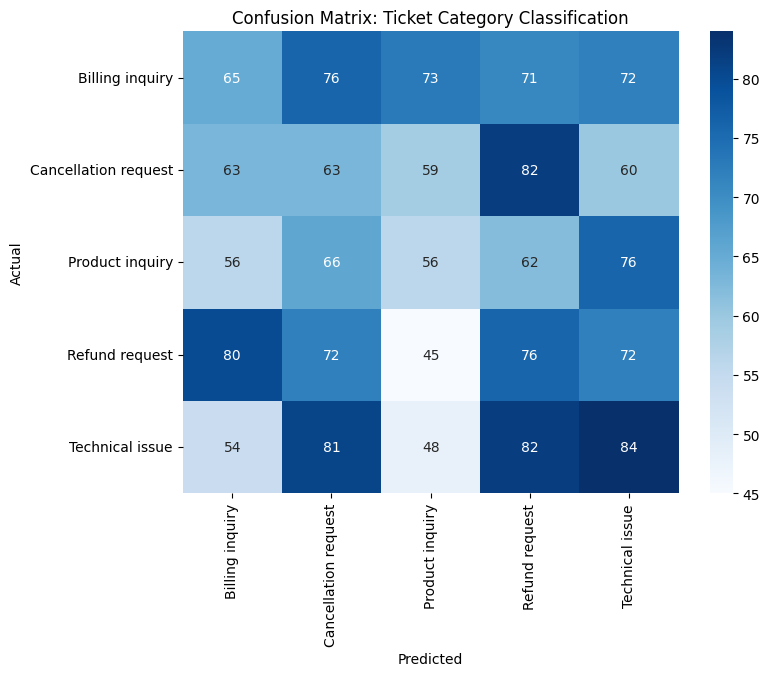


--- Ticket Priority Classification ---
Accuracy: 0.25
              precision    recall  f1-score   support

    Critical       0.24      0.25      0.24       411
        High       0.23      0.23      0.23       409
         Low       0.24      0.21      0.22       415
      Medium       0.28      0.30      0.29       459

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



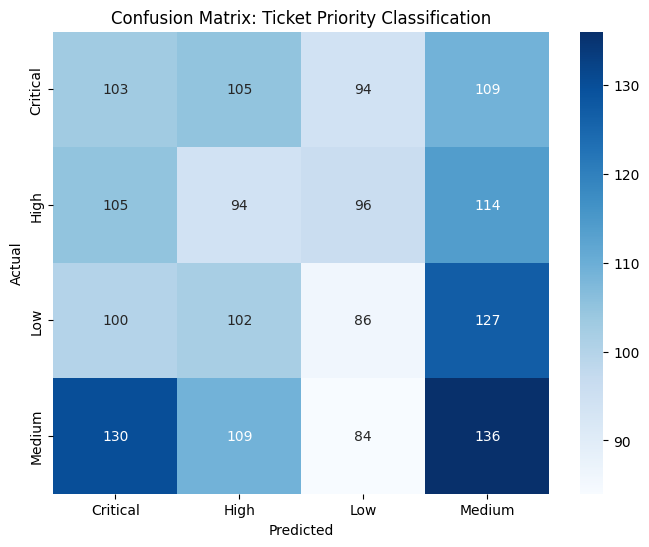


Ticket: I cannot log into my account and the screen shows a 404 error.
Predicted Category: Refund request
Predicted Priority: Medium

Ticket: I was charged twice for my monthly subscription.
Predicted Category: Technical issue
Predicted Priority: High


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. SETUP & DATA LOADING
# Change 'customer_support_tickets.csv' to your actual filename
try:
    df = pd.read_csv('customer_support_tickets.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")

# Check the first few rows to confirm column names
print(df[['Ticket Description', 'Ticket Type', 'Ticket Priority']].head())

# 2. PREPROCESSING
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

print("Cleaning text data... this may take a moment.")
df['cleaned_description'] = df['Ticket Description'].apply(clean_text)

# 3. ENCODING TARGETS
# Converting categories (Billing, Technical, etc.) into numbers
le_type = LabelEncoder()
le_priority = LabelEncoder()

df['type_label'] = le_type.fit_transform(df['Ticket Type'])
df['priority_label'] = le_priority.fit_transform(df['Ticket Priority'])

# 4. FEATURE EXTRACTION (TF-IDF)
tfidf = TfidfVectorizer(max_features=3000) # Top 3000 most important words
X = tfidf.fit_transform(df['cleaned_description'])

# Targets
y_type = df['type_label']
y_priority = df['priority_label']

# 5. DATA SPLITTING
X_train, X_test, y_type_train, y_type_test, y_priority_train, y_priority_test = train_test_split(
    X, y_type, y_priority, test_size=0.2, random_state=42
)

# 6. MODEL TRAINING
print("Training models...")

# Model for Category (Ticket Type)
type_model = RandomForestClassifier(n_estimators=100, random_state=42)
type_model.fit(X_train, y_type_train)

# Model for Priority
priority_model = RandomForestClassifier(n_estimators=100, random_state=42)
priority_model.fit(X_train, y_priority_train)

# 7. EVALUATION
def evaluate_model(model, X_test, y_test, label_encoder, title):
    y_pred = model.predict(X_test)
    print(f"\n--- {title} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model(type_model, X_test, y_type_test, le_type, "Ticket Category Classification")
evaluate_model(priority_model, X_test, y_priority_test, le_priority, "Ticket Priority Classification")

# 8. PREDICTION FUNCTION (The "Decision Support" System)
def classify_new_ticket(description):
    cleaned = clean_text(description)
    vectorized = tfidf.transform([cleaned])

    category = le_type.inverse_transform(type_model.predict(vectorized))[0]
    priority = le_priority.inverse_transform(priority_model.predict(vectorized))[0]

    print(f"\nTicket: {description}")
    print(f"Predicted Category: {category}")
    print(f"Predicted Priority: {priority}")

# Test with a custom example
classify_new_ticket("I cannot log into my account and the screen shows a 404 error.")
classify_new_ticket("I was charged twice for my monthly subscription.")